# Time Series Analisys on Geoespatial Data with Python


Author: João Otavio Nascimento Firigato

email: joaootavionf007@gmail.com

LinkedIn: https://www.linkedin.com/in/jo%C3%A3o-otavio-firigato-4876b3aa/


## First instructions:

✅ Access the link to join our private WhatsApp community for students: https://chat.whatsapp.com/EPn27ZgR07lF3e1vnj8FiI


❗ It is important to access the Whatsapp Group to get the Colab Notebooks, as the PDF files are protected from text copying.




# Chapter 12 - Anomaly and Outlier Detection

Anomaly detection is a data science application that combines several tasks such as classification, regression, and clustering. Anomaly detection is an essential tool for improving your ability to make better business decisions. It is a process in machine learning that identifies data points, events, and observations that deviate from the normal behavior of a data set. Time series anomaly detection is a way to gain insights into specific business strategies. Time series outlier detection warrants extensive exploration, given its potential to significantly influence any predictions we make.

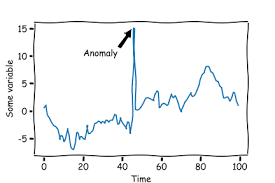

What is an Outlier: An observation that deviates so much from other observations that it raises suspicions that it was generated by a different mechanism.

Therefore, you can think of outliers as observations that do not follow the expected behavior.

## Types of outliers

Outliers in time series data can be classified into three main types. First, point outliers are individual data points that deviate significantly from the expected pattern in the data set. They usually arise due to measurement error or extreme but legitimate data variances. Second, contextual outliers, as the name suggests, are anomalous within a specific context. While they may appear normal in general circumstances, they become apparent when considering the temporal nature of the data. For example, high air conditioning sales in December may constitute a contextual outlier. Finally, collective outliers refer to a collection of data points that, as a whole, deviate from the expected behavior of the entire data set. They may not comprise individual outliers, but they can exhibit anomalous behavior when considered collectively, often violating the dynamics of the system. Identifying these outliers accurately is critical for robust time series analysis. In this article, we will focus on the first type of outliers.

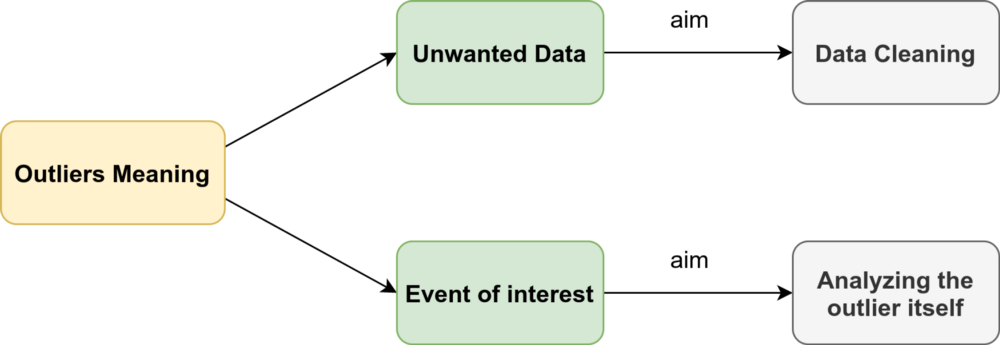

## Point outlier

A point outlier is a piece of data that behaves unusually at a specific time instance when compared to other values ​​in the time series (global outlier) or to its neighboring points (local outlier).

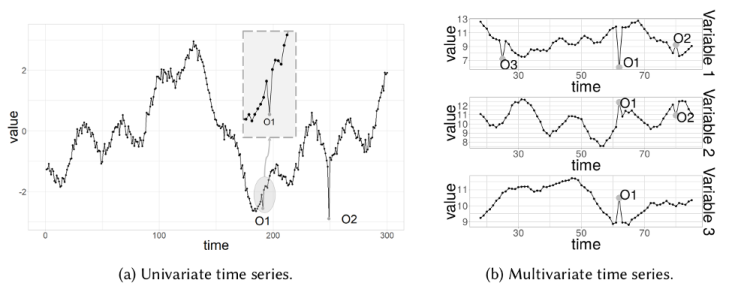

## Subsequence outlier

This means consecutive points in time whose joint behavior is unusual, although each observation individually is not necessarily a point outlier. Subsequence outliers can also be global or local, and can affect one (univariate subsequence outlier) or more (multivariate subsequence outlier) time-dependent variables.

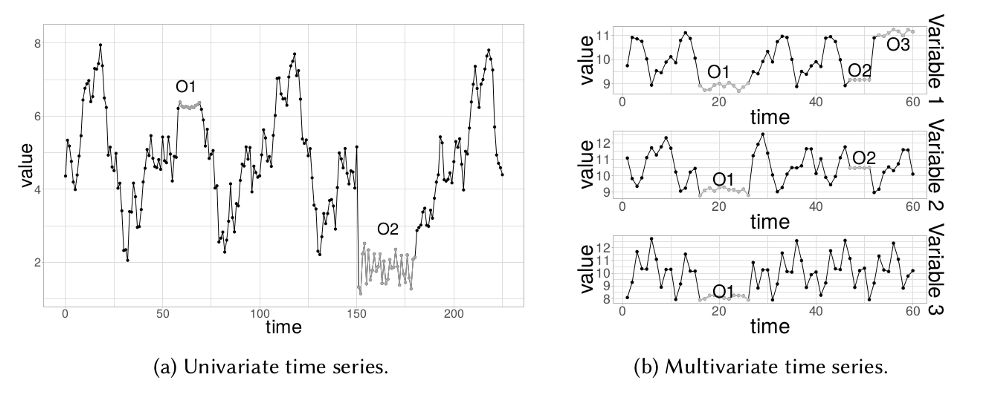

# Outlier detection methods

Let's access our example dataset in Drive to use in our use case:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Link to Dataset: https://drive.google.com/file/d/10omy6A3pjEAbQzISjglvSkpiCpBpx3A_/view?usp=sharing

In [ ]:
path = '/content/drive/MyDrive/Datasets_TS/Global Temperature.csv'

In [ ]:
df = pd.read_csv(path)

In [ ]:
df.head()

,Year,Month,Monthly Anomaly,Monthly Unc.,Annual Anomaly,Annual Unc,Five-Year Anomaly,Five-Year Unc.,Ten-Year Anomaly,Ten-Year Unc.,Twenty-Year Anomaly,Twenty-year Unc.
0,1850,1,-0.801,0.482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1850,2,-0.102,0.592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1850,3,-0.119,0.819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1850,4,-0.485,0.575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1850,5,-0.351,0.549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Let's adjust our dataframe to a time series:

In [ ]:
df.rename(columns={' Month': 'Month'}, inplace=True)

In [ ]:
df['Date'] = pd.to_datetime(df.Year.astype(str) + '/' + df.Month.astype(str) + '/01')

In [ ]:
df.set_index('Date', inplace=True)

In [ ]:
df_1900 = df[:'1900'].copy()

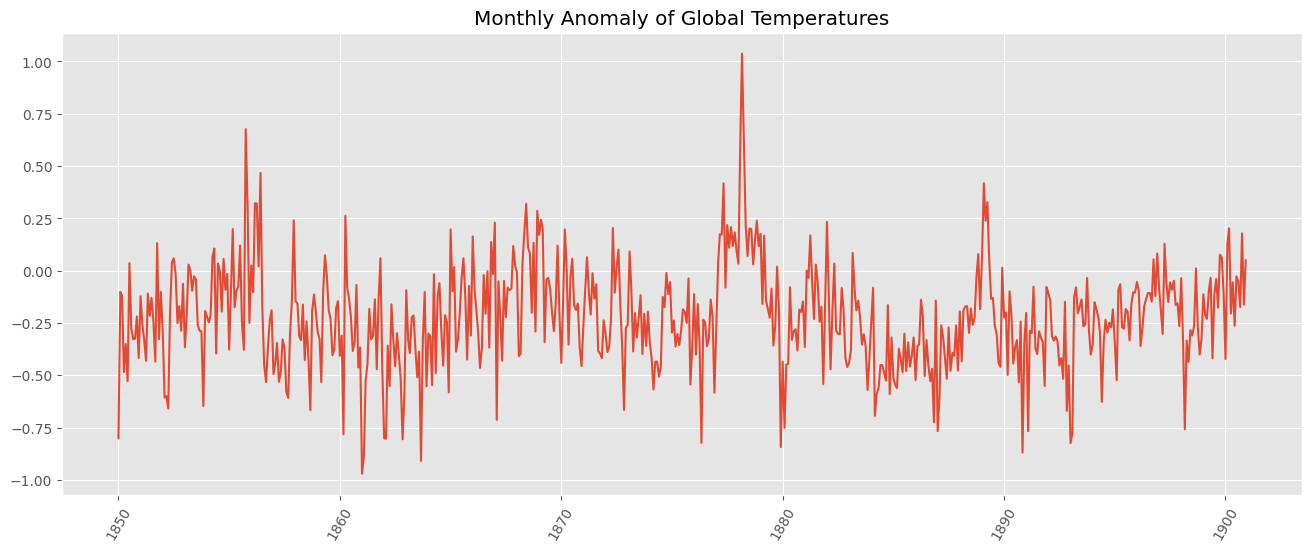

In [ ]:
plt.figure(figsize=(16,6))
plt.style.use("ggplot")
plt.plot(df_1900.index, df_1900['Monthly Anomaly'])
plt.title('Monthly Anomaly of Global Temperatures')
plt.xticks(rotation=60)
plt.show()

## Z-Score

The z-score is a statistical measure that indicates the number of standard deviations that a data point is above or below the mean. Typically, data points that have z-scores that fall beyond a certain threshold (e.g., 2 or 3 standard deviations from the mean) are considered outliers. Note that this method is highly susceptible to extreme values ​​in the data, as they will significantly impact the mean and standard deviation, leading to misleading z-scores for other data points. Additionally, it assumes normal distribution, which may not be true for small sample sizes.

In [ ]:
import numpy as np


df_1900['Z-Score'] = np.abs((df_1900['Monthly Anomaly'] - df_1900['Monthly Anomaly'].mean()) / df_1900['Monthly Anomaly'].std())
outliers_z_score = df_1900[df_1900['Z-Score'] > 2]

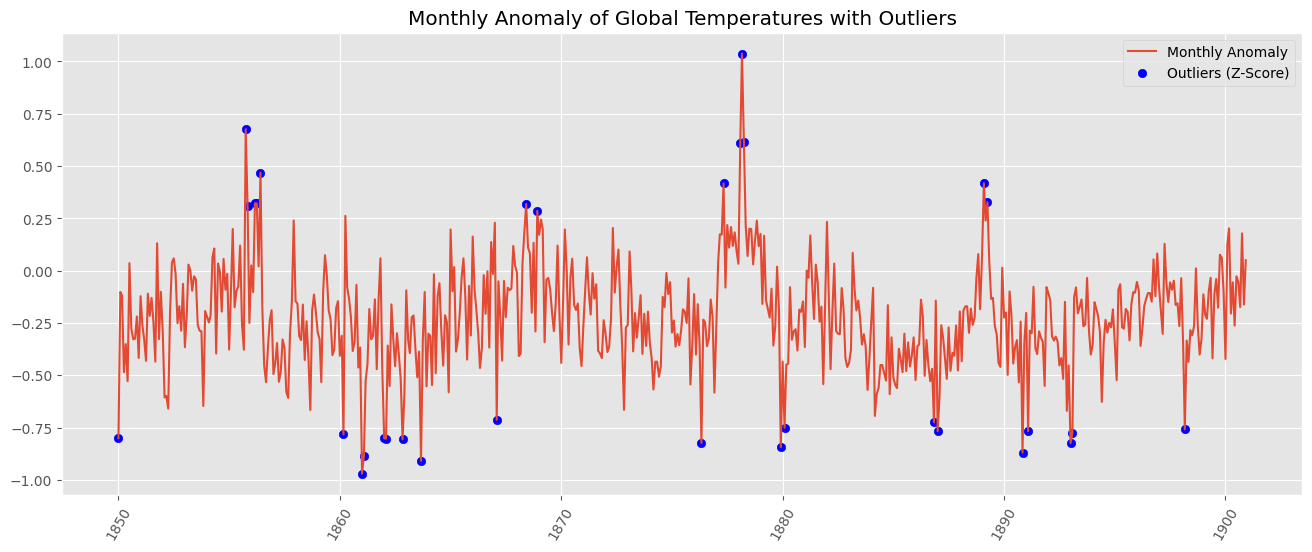

In [ ]:
plt.figure(figsize=(16, 6))
plt.style.use("ggplot")
plt.plot(df_1900.index, df_1900['Monthly Anomaly'], label='Monthly Anomaly')
plt.scatter(outliers_z_score.index, outliers_z_score['Monthly Anomaly'], color='blue', label='Outliers (Z-Score)')
plt.title('Monthly Anomaly of Global Temperatures with Outliers')
plt.xticks(rotation=60)
plt.legend()
plt.show()


In [ ]:
outliers_z_score

,Year,Month,Monthly Anomaly,Monthly Unc.,Annual Anomaly,Annual Unc,Five-Year Anomaly,Five-Year Unc.,Ten-Year Anomaly,Ten-Year Unc.,Twenty-Year Anomaly,Twenty-year Unc.,Z-Score
Date,,,,,,,,,,,,,
1850-01-01,1850,1,-0.801,0.482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.365659
1855-10-01,1855,10,0.676,0.586,0.051,0.307,-0.16,0.163,-0.2,0.131,NaN,NaN,3.677085
1855-11-01,1855,11,0.307,0.459,0.061,0.337,-0.161,0.161,-0.202,0.133,NaN,NaN,2.167422
1856-03-01,1856,3,0.322,0.696,0.052,0.375,-0.18,0.157,-0.216,0.145,NaN,NaN,2.228790
1856-04-01,1856,4,0.321,0.93,-0.035,0.354,-0.178,0.156,-0.216,0.145,NaN,NaN,2.224699
1856-06-01,1856,6,0.467,0.68,-0.076,0.347,-0.17,0.153,-0.217,0.144,NaN,NaN,2.822018
1860-03-01,1860,3,-0.782,0.414,-0.258,0.148,-0.309,0.116,-0.28,0.127,-0.218,0.108,2.287926
1861-01-01,1861,1,-0.970,0.659,-0.439,0.224,-0.344,0.105,-0.293,0.117,-0.213,0.105,3.057077
1861-02-01,1861,2,-0.885,0.373,-0.419,0.221,-0.343,0.108,-0.293,0.117,-0.212,0.105,2.709322


## IQR Method

The IQR (interquartile range) outlier detection method involves calculating the range between the first quartile (25th percentile) and the third quartile (75th percentile) of the data, known as the IQR. Data points that fall below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR are considered outliers. This method is robust to extreme values ​​and does not assume any specific distribution of the data, making it useful in a variety of scenarios for identifying potential outliers.

In [ ]:
Q1 = df_1900['Monthly Anomaly'].quantile(0.25)
Q3 = df_1900['Monthly Anomaly'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df_1900[(df_1900['Monthly Anomaly'] < lower_bound) | (df_1900['Monthly Anomaly'] > upper_bound)]

In [ ]:
outliers_iqr

,Year,Month,Monthly Anomaly,Monthly Unc.,Annual Anomaly,Annual Unc,Five-Year Anomaly,Five-Year Unc.,Ten-Year Anomaly,Ten-Year Unc.,Twenty-Year Anomaly,Twenty-year Unc.,Z-Score
Date,,,,,,,,,,,,,
1850-01-01,1850,1,-0.801,0.482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.365659
1855-10-01,1855,10,0.676,0.586,0.051,0.307,-0.16,0.163,-0.2,0.131,NaN,NaN,3.677085
1856-06-01,1856,6,0.467,0.68,-0.076,0.347,-0.17,0.153,-0.217,0.144,NaN,NaN,2.822018
1861-01-01,1861,1,-0.970,0.659,-0.439,0.224,-0.344,0.105,-0.293,0.117,-0.213,0.105,3.057077
1861-02-01,1861,2,-0.885,0.373,-0.419,0.221,-0.343,0.108,-0.293,0.117,-0.212,0.105,2.709322
1862-01-01,1862,1,-0.801,0.285,-0.385,0.131,-0.363,0.108,-0.295,0.099,-0.211,0.101,2.365659
1862-02-01,1862,2,-0.803,0.382,-0.398,0.128,-0.364,0.109,-0.298,0.099,-0.21,0.101,2.373842
1862-11-01,1862,11,-0.806,0.659,-0.388,0.135,-0.359,0.126,-0.276,0.094,-0.208,0.095,2.386115
1863-09-01,1863,9,-0.909,0.317,-0.397,0.15,-0.307,0.119,-0.256,0.094,-0.212,0.088,2.807512


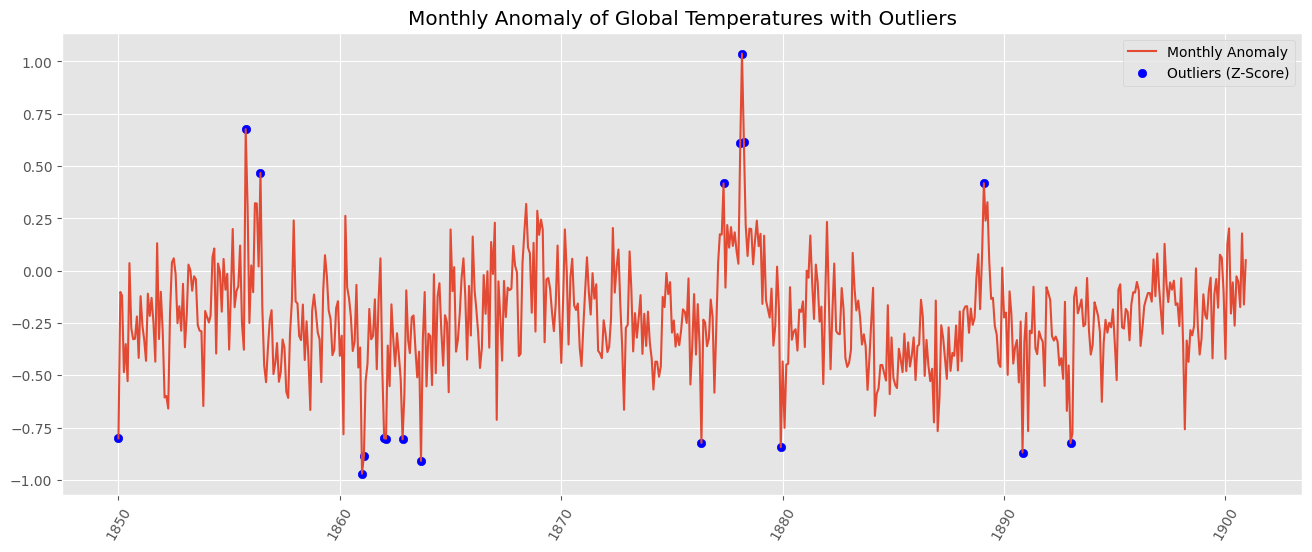

In [ ]:
plt.figure(figsize=(16, 6))
plt.style.use("ggplot")
plt.plot(df_1900.index, df_1900['Monthly Anomaly'], label='Monthly Anomaly')
plt.scatter(outliers_iqr.index, outliers_iqr['Monthly Anomaly'], color='blue', label='Outliers (Z-Score)')
plt.title('Monthly Anomaly of Global Temperatures with Outliers')
plt.xticks(rotation=60)
plt.legend()
plt.show()


## Local Outlier Factor

Local Outlier Factor (LOF) is a density-based algorithm used to detect outliers in datasets. It measures the local deviation of a given sample’s density from its neighbors. It is particularly effective for datasets containing regions of varying density. LOF assigns scores to each data point in a dataset, where a higher LOF score indicates that the data point is more likely to be an outlier. The LOF score of a data point is essentially a ratio of the data point’s average local density and the average local densities of its nearest neighbors. If a data point’s local density is significantly lower than that of its neighbors, it is considered an outlier. This means that LOF can effectively identify both global and local outliers because it takes into account the local context of each data point.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
df_1900['outlier'] = lof.fit_predict(df_1900[['Monthly Anomaly']])
outliers_lof = df_1900[df_1900['outlier'] == -1]

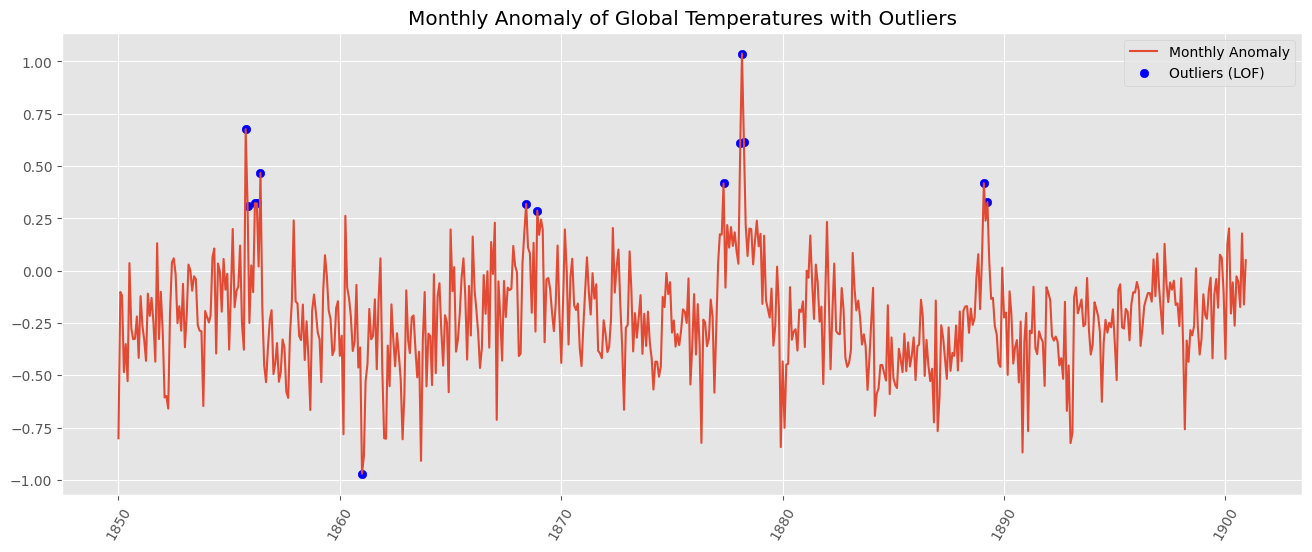

In [ ]:
plt.figure(figsize=(16, 6))
plt.style.use("ggplot")
plt.plot(df_1900.index, df_1900['Monthly Anomaly'], label='Monthly Anomaly')
plt.scatter(outliers_lof.index, outliers_lof['Monthly Anomaly'], color='blue', label='Outliers (LOF)')
plt.title('Monthly Anomaly of Global Temperatures with Outliers')
plt.xticks(rotation=60)
plt.legend()
plt.show()

## Isolation Forests

Isolation Forest is a tree-based anomaly detection algorithm. For the target variable, the algorithm chooses a random "split value." This split value is a specific point between the smallest (minimum) and largest (maximum) values ​​that the chosen feature takes on in the dataset. The data is then split into two groups based on this split value: one group includes all data points with the chosen feature value less than or equal to the split value, and the other group includes all points with the feature value greater than the split value. By repeating this process recursively on each resulting subset of the data, the algorithm builds a decision tree where each split separates data points based on the randomly selected feature value relative to the random split value. Outliers are generally fewer and less numerous and distinct, so they are isolated closer to the root of the tree, resulting in shorter paths.

In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
model = IsolationForest(contamination=0.05, random_state=42)

X = df_1900[['Monthly Anomaly']]
model.fit(X)

df_1900['Anomaly'] = model.predict(X)

We selected the anomalies:

In [ ]:
outliers_isofor = df_1900[df_1900['Anomaly'] == -1]

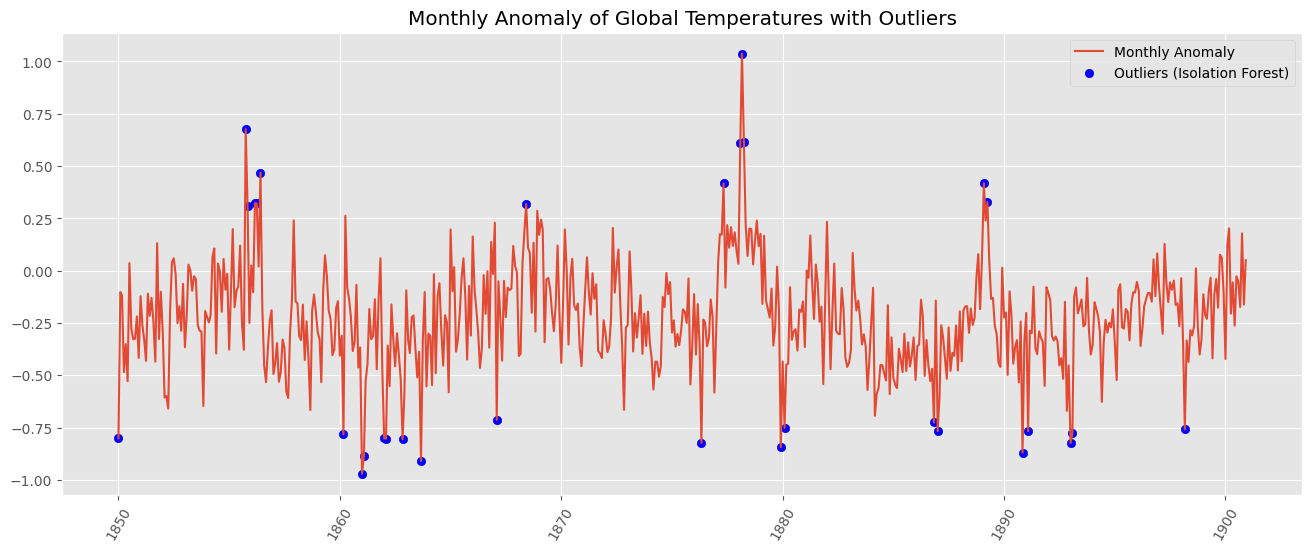

In [ ]:
plt.figure(figsize=(16, 6))
plt.style.use("ggplot")
plt.plot(df_1900.index, df_1900['Monthly Anomaly'], label='Monthly Anomaly')
plt.scatter(outliers_isofor.index, outliers_isofor['Monthly Anomaly'], color='blue', label='Outliers (Isolation Forest)')
plt.title('Monthly Anomaly of Global Temperatures with Outliers')
plt.xticks(rotation=60)
plt.legend()
plt.show()

## Series Decomposition

Series Decomposition is a method used in time series analysis where a time series is decomposed into trend, seasonal, and residual components. This can be achieved using methods such as additive or multiplicative decomposition, or more sophisticated methods such as STL (Seasonal and Trend Decomposition Using Loess).

For outlier detection, we typically focus on the residual component. Since the trend and seasonal components are removed, any significant spike or dip in the residual component (which should ideally be random noise) can be considered an outlier. This makes Series Decomposition a valuable technique for time series outlier detection.

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

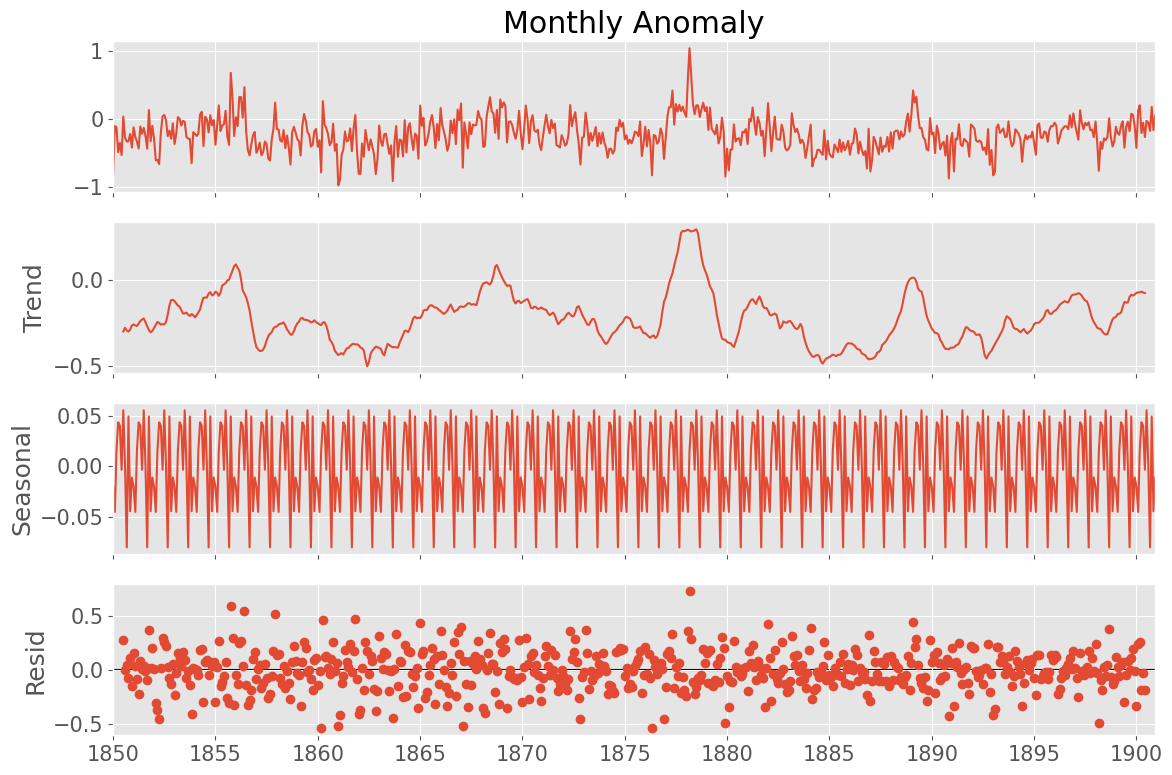

In [ ]:
plt.rc('figure',figsize=(12,8))
plt.rc('font',size=15)
result = seasonal_decompose(df_1900['Monthly Anomaly'],model='additive')
fig = result.plot()

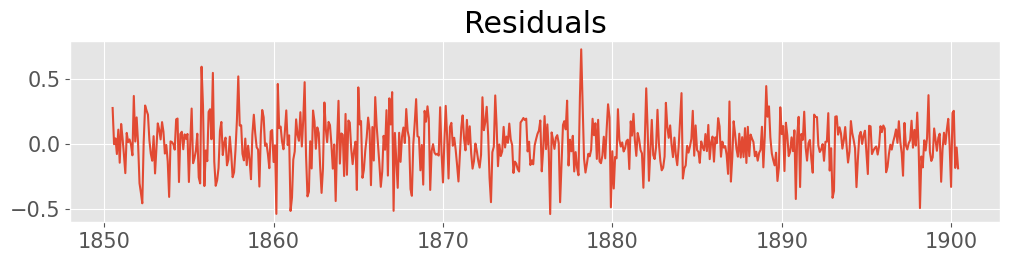

In [ ]:
plt.subplot(3,1,3)
plt.plot(result.resid)
plt.title('Residuals')

plt.show()

From the residuals, we calculate the mean and standard deviation to obtain the lower and upper bounds:

In [ ]:
res_mean = result.resid.mean()
resid_std = result.resid.std()

lower_bound = res_mean - 3*resid_std
upper_bound = res_mean + 3*resid_std

In [ ]:
upper_bound

np.float64(0.5519172730552877)

Text(0, 0.5, 'Mean temperature')

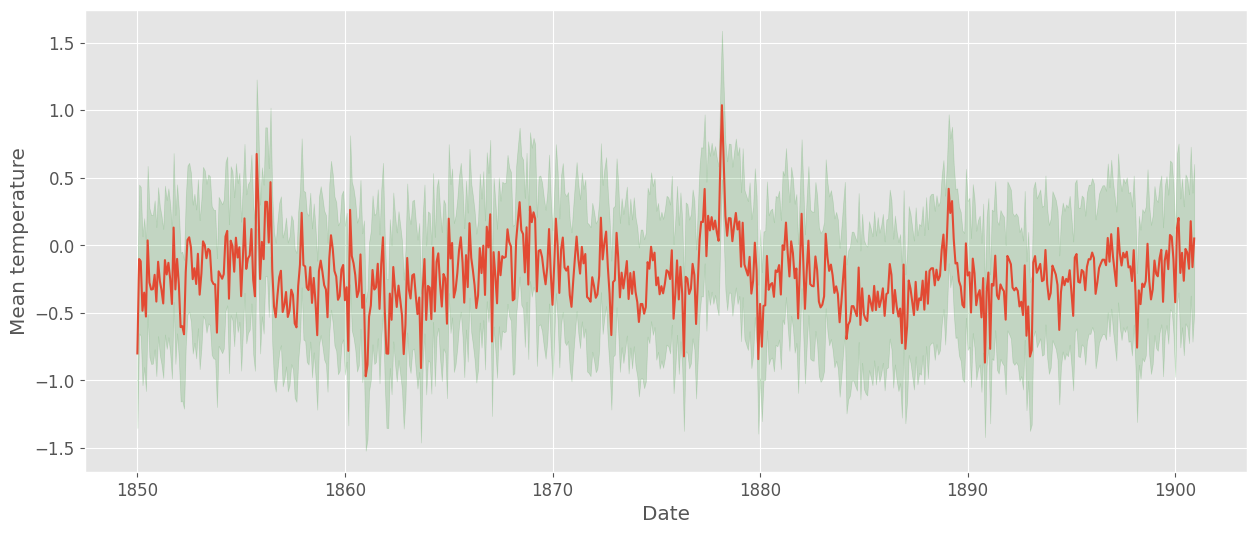

In [ ]:
plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(15, 6))

plt.plot(df_1900['Monthly Anomaly'])
plt.fill_between(df_1900['Monthly Anomaly'].index, df_1900['Monthly Anomaly'] - lower_bound, df_1900['Monthly Anomaly'] + lower_bound, color = 'g', alpha = 0.15)

ax.set_xlabel('Date')
ax.set_ylabel('Mean temperature')

Anomalies are outside the lower and upper limits:

In [ ]:
anomalies = df_1900['Monthly Anomaly'][(df_1900['Monthly Anomaly'] < lower_bound) | (df_1900['Monthly Anomaly'] > upper_bound)]

In [ ]:
anomalies

,Monthly Anomaly
Date,
1850-01-01,-0.801
1852-02-01,-0.606
1852-03-01,-0.599
1852-04-01,-0.659
1853-11-01,-0.647
1855-10-01,0.676
1857-08-01,-0.579
1857-09-01,-0.608
1858-09-01,-0.666


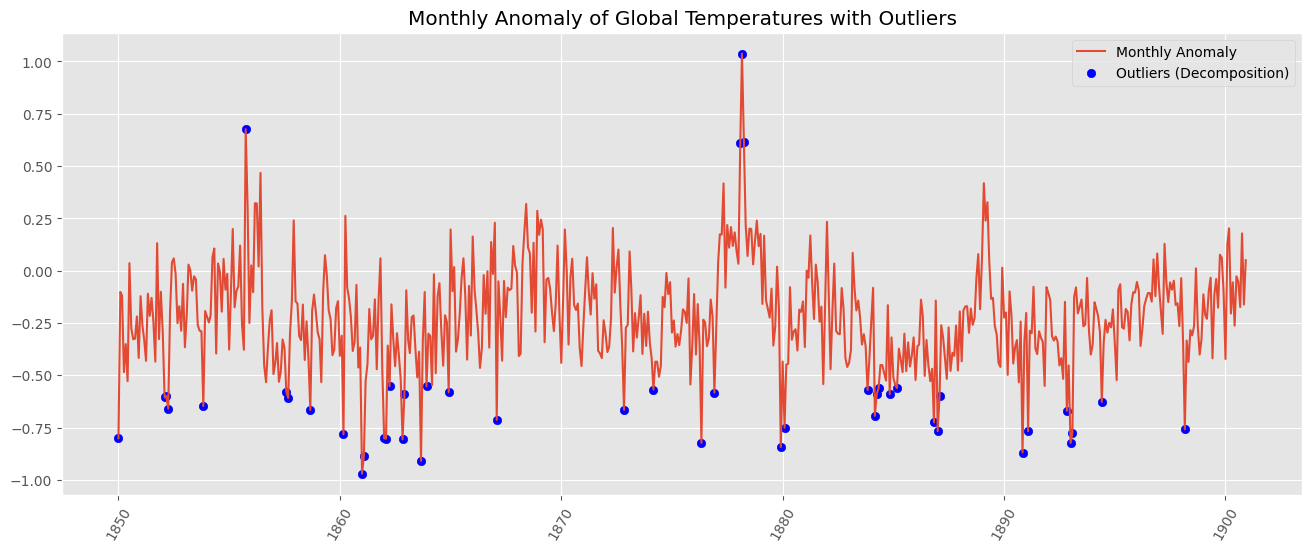

In [ ]:
plt.figure(figsize=(16, 6))
plt.style.use("ggplot")
plt.plot(df_1900.index, df_1900['Monthly Anomaly'], label='Monthly Anomaly')
plt.scatter(anomalies.index, anomalies, color='blue', label='Outliers (Decomposition)')
plt.title('Monthly Anomaly of Global Temperatures with Outliers')
plt.xticks(rotation=60)
plt.legend()
plt.show()

## Facebook's Prophet Model

Facebook Prophet is an open-source library developed by Facebook's internal data science team to solve time series-based forecasting problems. It is a quick and easy way to create forecasts. It can make predictions about future events based on historical data.

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

We prepare our dataset to apply Prophet:

In [ ]:
df = pd.DataFrame()
df['ds'] = df_1900.index
df['y'] = df_1900['Monthly Anomaly'].values

In [ ]:
def fit_predict_model(dataframe, interval_width = 0.99, changepoint_range = 0.8):
    m = Prophet(daily_seasonality = False, yearly_seasonality = False, weekly_seasonality = False,
                seasonality_mode = 'additive',
                interval_width = interval_width,
                changepoint_range = changepoint_range)
    m = m.fit(dataframe)
    forecast = m.predict(dataframe)
    forecast['fact'] = dataframe['y'].reset_index(drop = True)
    return forecast

pred = fit_predict_model(df)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp8e0e74q2/7649meoc.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8e0e74q2/_8446wlz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=3187', 'data', 'file=/tmp/tmp8e0e74q2/7649meoc.json', 'init=/tmp/tmp8e0e74q2/_8446wlz.json', 'output', 'file=/tmp/tmp8e0e74q2/prophet_modeligrcmvdz/prophet_model-20250527234426.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:44:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:44:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


After applying Prophet, we will obtain the anomalies that are outside the lower and upper limits:

In [ ]:
def detect_anomalies(forecast):
    forecasted = forecast[['ds','trend', 'yhat', 'yhat_lower', 'yhat_upper', 'fact']].copy()

    forecasted['anomaly'] = 0
    forecasted.loc[forecasted['fact'] > forecasted['yhat_upper'], 'anomaly'] = 1
    forecasted.loc[forecasted['fact'] < forecasted['yhat_lower'], 'anomaly'] = -1

    #anomaly importances
    forecasted['importance'] = 0
    forecasted.loc[forecasted['anomaly'] ==1, 'importance'] = (forecasted['fact'] - forecasted['yhat_upper'])/forecast['fact']
    forecasted.loc[forecasted['anomaly'] ==-1, 'importance'] = (forecasted['yhat_lower'] - forecasted['fact'])/forecast['fact']

    return forecasted

pred = detect_anomalies(pred)

<ipython-input-42-18df92a84b25>:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.46397406 0.04028923 0.23315508 0.58450224 0.45702309]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  forecasted.loc[forecasted['anomaly'] ==1, 'importance'] = (forecasted['fact'] - forecasted['yhat_upper'])/forecast['fact']


In [ ]:
pred.set_index('ds', inplace=True)

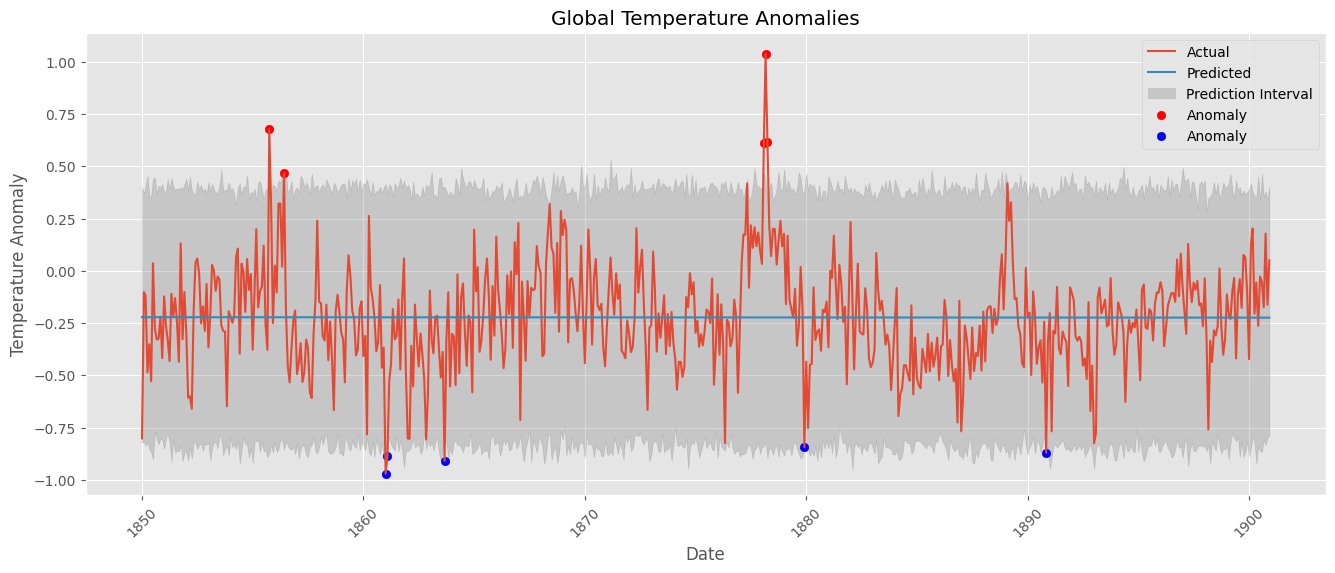

In [ ]:
# prompt: plot pred with lower and upper values

plt.figure(figsize=(16, 6))
plt.plot(pred.index, pred['fact'], label='Actual')
plt.plot(pred.index, pred['yhat'], label='Predicted')
plt.fill_between(pred.index, pred['yhat_lower'], pred['yhat_upper'], color='gray', alpha=0.3, label='Prediction Interval')
plt.scatter(pred[pred['anomaly'] == 1].index, pred[pred['anomaly'] == 1]['fact'], color='red', label='Anomaly')
plt.scatter(pred[pred['anomaly'] == -1].index, pred[pred['anomaly'] == -1]['fact'], color='blue', label='Anomaly')
plt.title('Global Temperature Anomalies')
plt.xlabel('Date')
plt.ylabel('Temperature Anomaly')
plt.xticks(rotation=45)
plt.legend()
plt.show()


## Thank you! See you in the next Chapter!

References:

https://medium.com/@alex.eslava96/outlier-detection-techniques-for-time-series-9868db2875c2

https://www.kaggle.com/code/kmkarakaya/anomaly-detection-in-time-series

https://neptune.ai/blog/anomaly-detection-in-time-series

https://medium.com/@reza.rajabi/outlier-and-anomaly-detection-using-facebook-prophet-in-python-3a83d58b1bdf

https://www.kaggle.com/code/pythonafroz/anomaly-detection-using-isolation-forest

https://www.kaggle.com/code/mehanat96/anomaly-detection-using-stl